    Income  Limit  Rating  Cards  Age  Education  Gender Student Married  \
0   14.891   3606     283      2   34         11    Male      No     Yes   
1  106.025   6645     483      3   82         15  Female     Yes     Yes   
2  104.593   7075     514      4   71         11    Male      No      No   
3  148.924   9504     681      3   36         11  Female      No      No   
4   55.882   4897     357      2   68         16    Male      No     Yes   
5   80.180   8047     569      4   77         10    Male      No      No   
6   20.996   3388     259      2   37         12  Female      No      No   
7   71.408   7114     512      2   87          9    Male      No      No   
8   15.125   3300     266      5   66         13  Female      No      No   
9   71.061   6819     491      3   41         19  Female     Yes     Yes   

          Ethnicity  Balance  
0         Caucasian      333  
1             Asian      903  
2             Asian      580  
3             Asian      964  
4       

<Figure size 1200x1000 with 0 Axes>

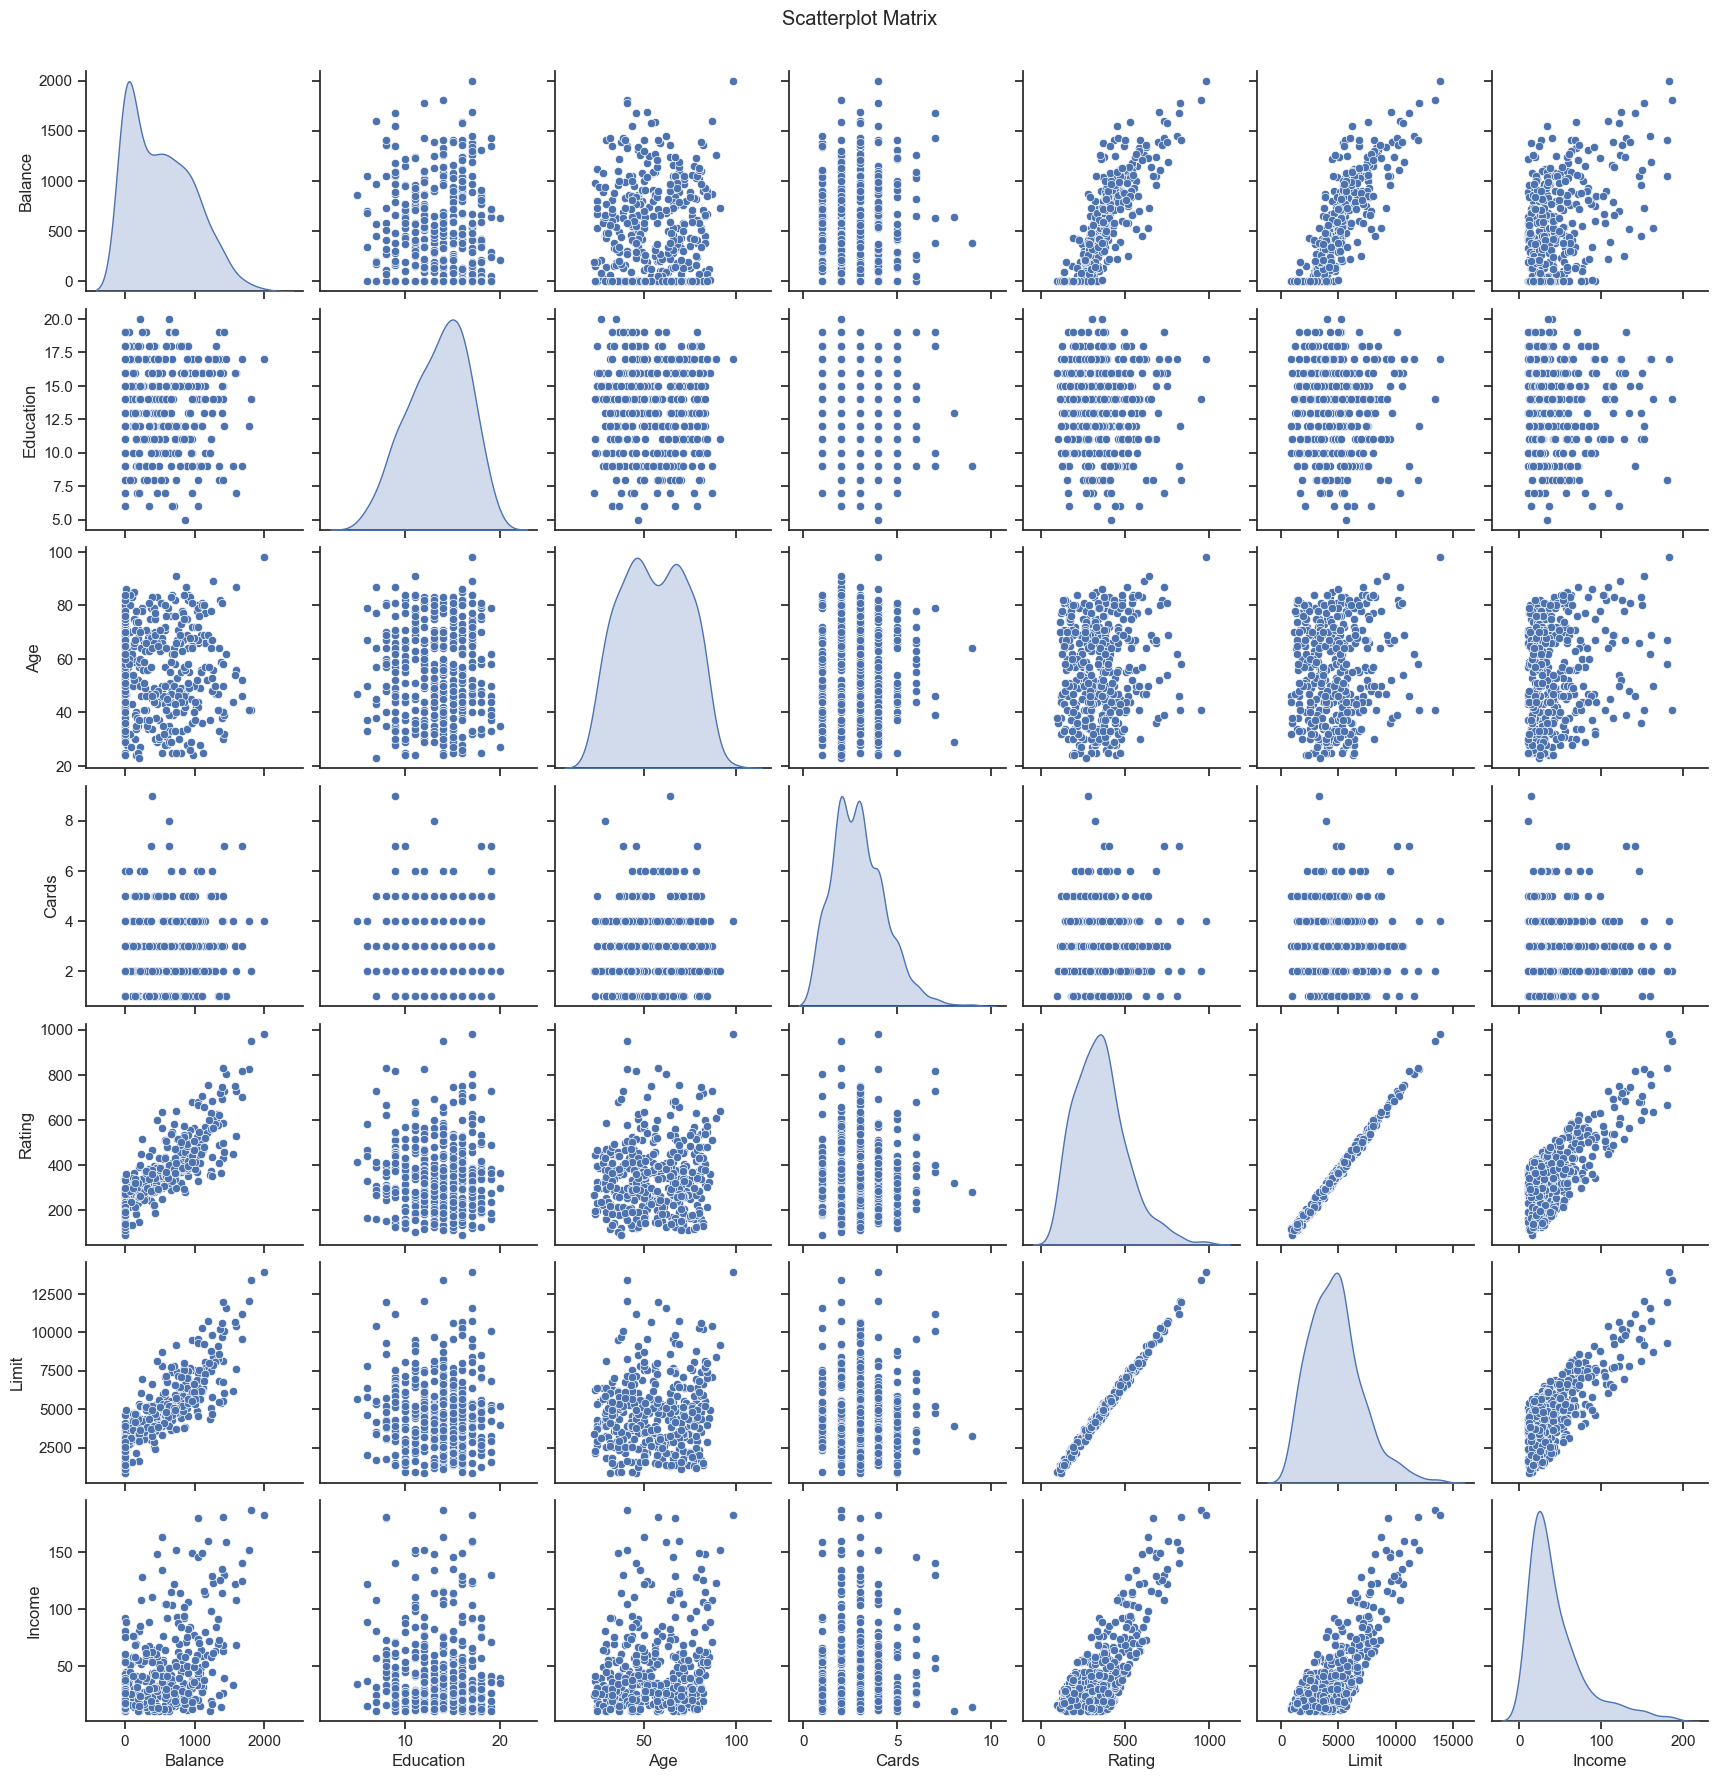

['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Gender', 'Student', 'Married', 'Ethnicity']
Evaluating models with 10 predictors...
Evaluating models with 9 predictors...
Evaluating models with 8 predictors...
Evaluating models with 7 predictors...
Evaluating models with 6 predictors...
Evaluating models with 5 predictors...
Evaluating models with 4 predictors...
Evaluating models with 3 predictors...
Evaluating models with 2 predictors...
Evaluating models with 1 predictors...


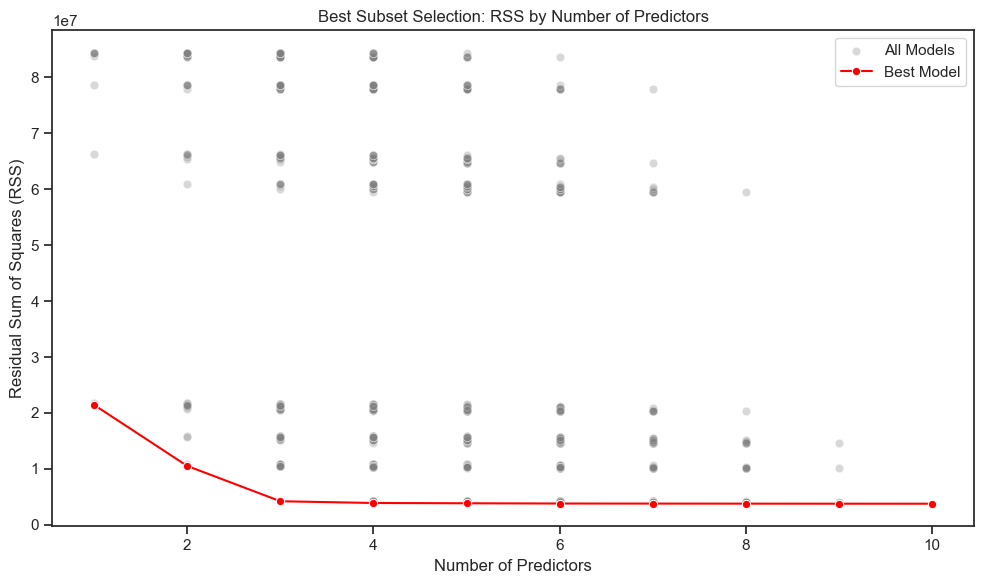

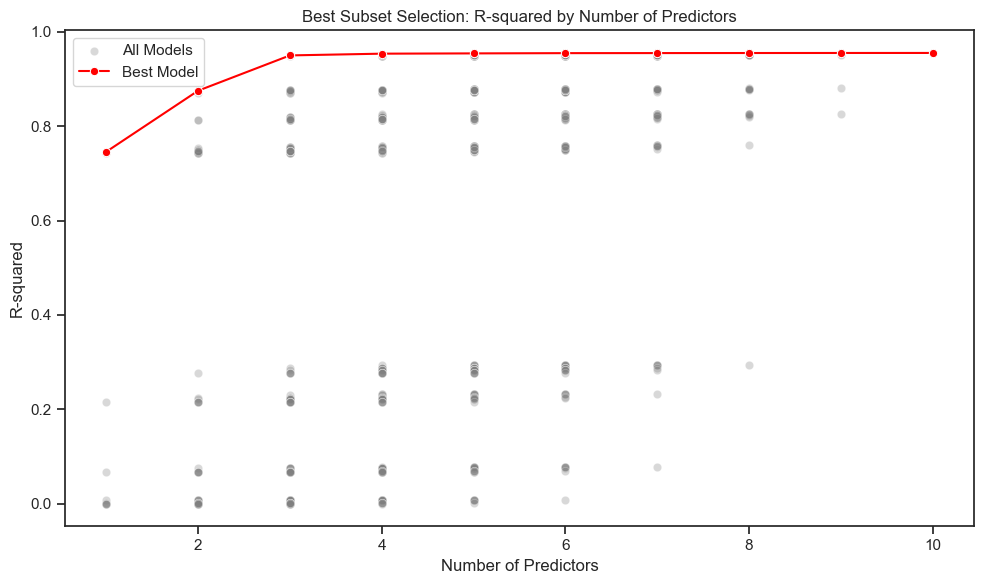

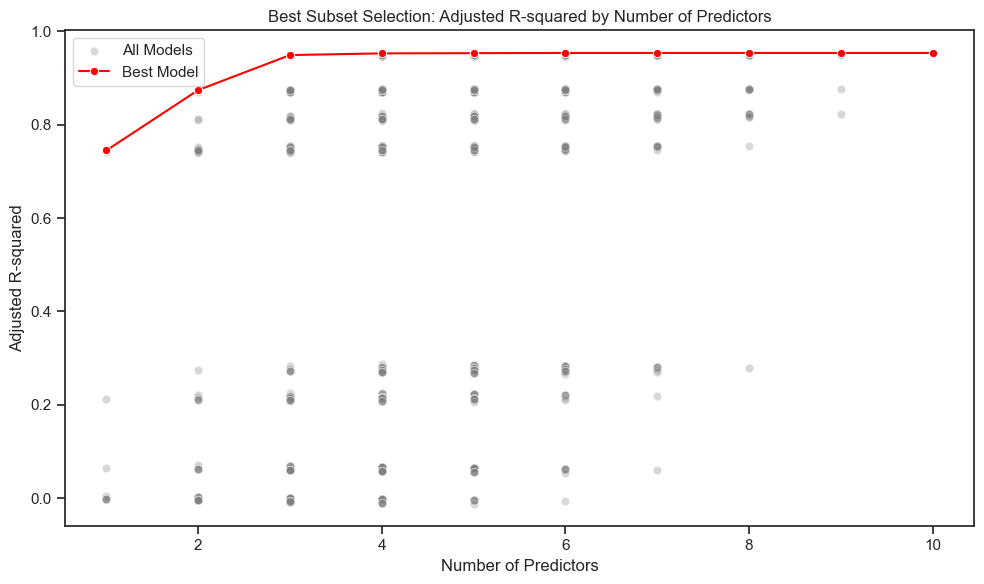

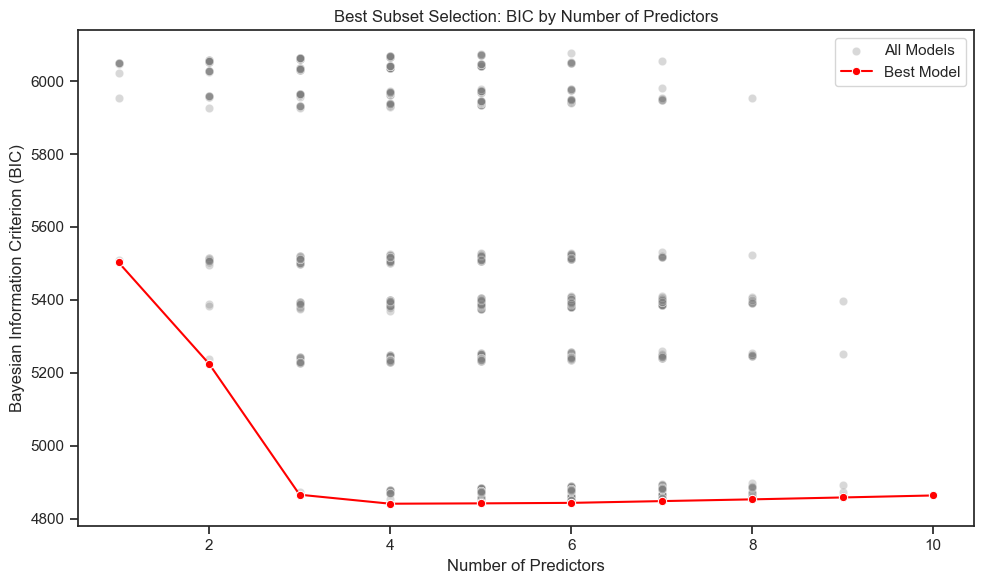

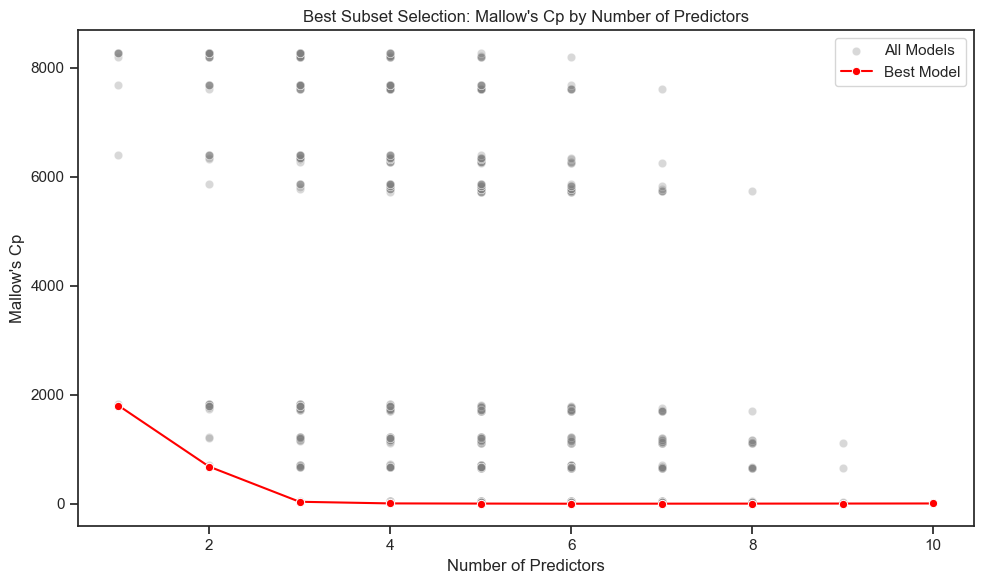


Best Models for Each Number of Predictors:
      Num_Predictors                                         Predictors  \
1015               1                                          (Rating,)   
969                2                                   (Income, Rating)   
860                3                          (Income, Rating, Student)   
648                4                    (Income, Limit, Cards, Student)   
389                5            (Income, Limit, Rating, Cards, Student)   
178                6       (Income, Limit, Rating, Cards, Age, Student)   
64                 7  (Income, Limit, Rating, Cards, Age, Student, E...   
18                 8  (Income, Limit, Rating, Cards, Age, Gender, St...   
5                  9  (Income, Limit, Rating, Cards, Age, Gender, St...   
0                 10  (Income, Limit, Rating, Cards, Age, Education,...   

               RSS  R_squared  Adj_R_squared          BIC           Cp  
1015  2.143512e+07   0.745848       0.745210  5502.764477

In [14]:
########## best subset selection for linear model on Credit data
import pprint
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Load the Credit Dataset

Credit = pd.read_csv('Credit.csv')
Credit = Credit.drop('ID', axis=1)
print(Credit.head(10))
print(Credit.shape)
[num_samples,num_predictors]=Credit.shape

Credit['Gender'] = Credit['Gender'].map({' Male': 1, 'Female': 0})
Credit['Student'] = Credit['Student'].map({'Yes': 1, 'No': 0})
Credit['Married'] = Credit['Married'].map({'Yes': 1, 'No': 0})
Credit['Ethnicity'] = Credit['Ethnicity'].map({"Asian": 2, 'Caucasian': 1, 'African American': 0})

# 2. Scatterplot Matrix
selected_columns=['Balance','Education','Age','Cards','Rating','Limit','Income']
# Plot scatterplot matrix
sns.set(style="ticks", color_codes=True)
plt.figure(figsize=(12, 10))
sns.pairplot(Credit[selected_columns], diag_kind='kde')
plt.suptitle("Scatterplot Matrix", y=1.02)
plt.show()

# 3. Best Subset Selection
# --------------------------------
# We'll perform exhaustive best subset selection for models with up to 10 predictors.

# Define target variable and predictors
target = 'Balance'
predictors = [col for col in Credit.columns if col != target]
print(predictors)
# Set maximum number of predictors
nvmax = 10

# Initialize lists to store model statistics
model_stats = []

# Iterate over number of predictors from 1 to nvmax
for k in range(nvmax ,0,-1):
    print(f"Evaluating models with {k} predictors...")
    # Generate all possible combinations of predictors of size k
    subsets = list(combinations(predictors, k))
    for subset in subsets:
        # Prepare the design matrix
        X_subset = Credit[list(subset)]
        X_subset = sm.add_constant(X_subset)  # Adds a constant term to the predictor
        # Fit the model using Ordinary Least Squares
        model = sm.OLS(Credit[target], X_subset).fit()
        
        # Calculate RSS
        rss = sum(model.resid ** 2)
        
        # Calculate R-squared
        rsq = model.rsquared
        
        # Calculate Adjusted R-squared
        adj_rsq = model.rsquared_adj
        
        # Calculate BIC
        bic = model.bic
        
        # Calculate Mallow's Cp
        # Cp = RSS / MSE_full - (n - 2p)
        # Estimate MSE from the full model (using all predictors)
        # This requires the full model's RSS and degrees of freedom
        # Fit the full model if k == nvmax
        if k == nvmax:
            full_model = model
            mse_full = full_model.mse_resid
        # For other models, use mse_full from the full model
        cp = (rss / mse_full) - (num_samples - 2 * k)
        
        # Store the statistics
        model_stats.append({
            'Num_Predictors': k,
            'Predictors': subset,
            'RSS': rss,
            'R_squared': rsq,
            'Adj_R_squared': adj_rsq,
            'BIC': bic,
            'Cp': cp
        })

# Convert the list of dictionaries to a DataFrame
model_stats_df = pd.DataFrame(model_stats)


# 4. Identifying Best Models per Number of Predictors
# --------------------------------
# For each k, find the model with the lowest RSS, highest R-squared, etc.

best_models = model_stats_df.loc[model_stats_df.groupby('Num_Predictors')['RSS'].idxmin()]

# 5. Plotting Model Statistics
# --------------------------------

# Function to plot metrics
def plot_metric(metric, ylabel, title):
    plt.figure(figsize=(10, 6))
    
    # Plot all models in grey
    sns.scatterplot(data=model_stats_df, x='Num_Predictors', y=metric, color='grey', alpha=0.3, label='All Models')
    
    # Plot best models in red
    sns.lineplot(data=best_models, x='Num_Predictors', y=metric, color='red', marker='o', label='Best Model')
    
    plt.title(title)
    plt.xlabel('Number of Predictors')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot RSS
plot_metric(metric='RSS', ylabel='Residual Sum of Squares (RSS)', title='Best Subset Selection: RSS by Number of Predictors')

# Plot R-squared
plot_metric(metric='R_squared', ylabel='R-squared', title='Best Subset Selection: R-squared by Number of Predictors')

# Plot Adjusted R-squared
plot_metric(metric='Adj_R_squared', ylabel='Adjusted R-squared', title='Best Subset Selection: Adjusted R-squared by Number of Predictors')

# Plot BIC
plot_metric(metric='BIC', ylabel='Bayesian Information Criterion (BIC)', title='Best Subset Selection: BIC by Number of Predictors')

# Plot Mallow's Cp
plot_metric(metric='Cp', ylabel="Mallow's Cp", title="Best Subset Selection: Mallow's Cp by Number of Predictors")

# 6. Display Best Models with Highest Metrics
# --------------------------------
# Optionally, display the best models' details
print("\nBest Models for Each Number of Predictors:")
print(best_models[['Num_Predictors', 'Predictors', 'RSS', 'R_squared', 'Adj_R_squared', 'BIC', 'Cp']])

# 7. Interpretation
# --------------------------------
print("\nInterpretation of Plots:")
print("""
1. **RSS Plot:** Shows the Residual Sum of Squares for all models. The best model for each number of predictors has the lowest RSS.

2. **R-squared Plot:** Indicates how well each model explains the variability of the target variable. The best model maximizes R-squared.

3. **Adjusted R-squared Plot:** Adjusts R-squared for the number of predictors, preventing overestimation when adding more variables. The best model has the highest Adjusted R-squared.

4. **BIC Plot:** Penalizes models with more predictors to prevent overfitting. The best model typically has the lowest BIC.

5. **Mallow's Cp Plot:** Helps in identifying models with significant predictors. A model with Cp ≈ p (number of predictors) is considered ideal. The best model aims for Cp close to the number of predictors.
""")

    Income  Limit  Rating  Cards  Age  Education  Gender Student Married  \
0   14.891   3606     283      2   34         11    Male      No     Yes   
1  106.025   6645     483      3   82         15  Female     Yes     Yes   
2  104.593   7075     514      4   71         11    Male      No      No   
3  148.924   9504     681      3   36         11  Female      No      No   
4   55.882   4897     357      2   68         16    Male      No     Yes   
5   80.180   8047     569      4   77         10    Male      No      No   
6   20.996   3388     259      2   37         12  Female      No      No   
7   71.408   7114     512      2   87          9    Male      No      No   
8   15.125   3300     266      5   66         13  Female      No      No   
9   71.061   6819     491      3   41         19  Female     Yes     Yes   

          Ethnicity  Balance  
0         Caucasian      333  
1             Asian      903  
2             Asian      580  
3             Asian      964  
4       

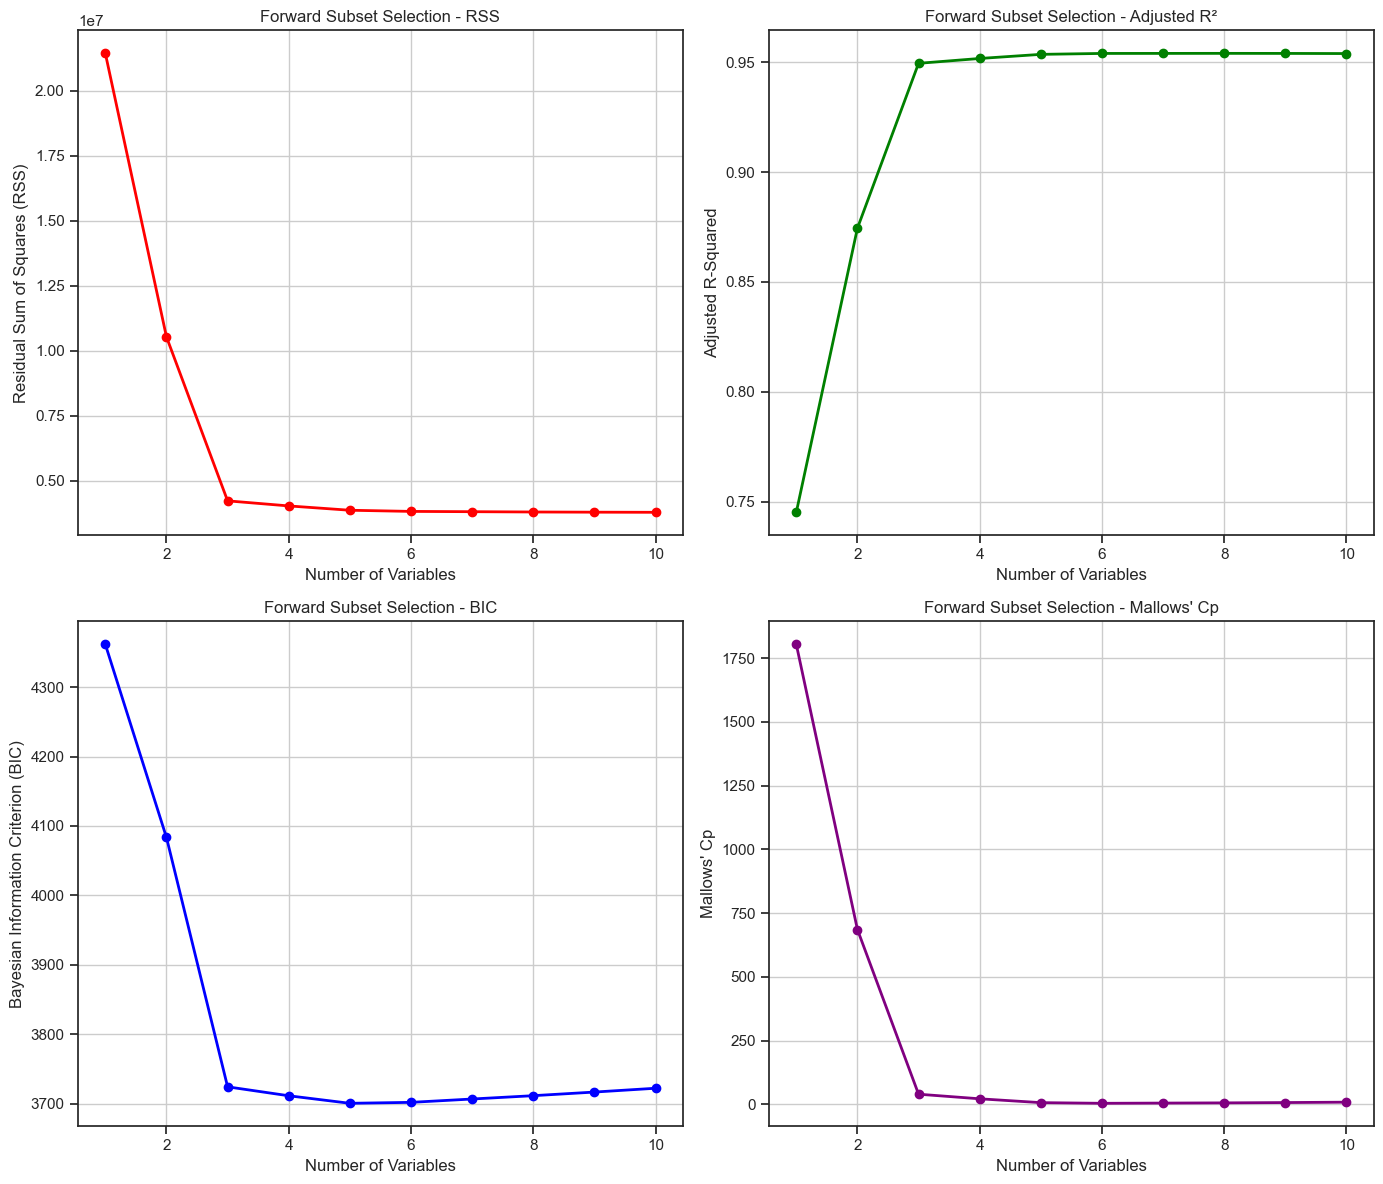

In [5]:
######## forward subset selection on Credit data
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Function to compute evaluation metrics
def compute_metrics(y, y_pred, p, n, sigma2):
    rss = np.sum((y - y_pred) ** 2)
    tss = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - rss / tss
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    bic = n * np.log(rss / n) + p * np.log(n)
    cp = rss / sigma2 - n + 2 * p
    return rss, adj_r2, bic, cp

# ---------------------------------------------------
# 1. Load and Preview the Credit Dataset
# ---------------------------------------------------

Credit = pd.read_csv('Credit.csv')
Credit = Credit.drop('ID', axis=1)
print(Credit.head(10))
[num_samples,num_predictors]=Credit.shape

Credit['Gender'] = Credit['Gender'].map({' Male': 1, 'Female': 0})
Credit['Student'] = Credit['Student'].map({'Yes': 1, 'No': 0})
Credit['Married'] = Credit['Married'].map({'Yes': 1, 'No': 0})
Credit['Ethnicity'] = Credit['Ethnicity'].map({"Asian": 2, 'Caucasian': 1, 'African American': 0})

# ---------------------------------------------------
# 2. Forward Subset Selection
# ---------------------------------------------------

# Define response and predictors
y = Credit['Balance']
X = Credit.drop('Balance', axis=1)

# Fit the full model to estimate sigma^2 for Mallows' Cp
X_full = sm.add_constant(X)
full_model = sm.OLS(y, X_full).fit()
sigma2 = full_model.mse_resid

# Initialize lists to store metrics and selected features
max_features = min(11, X.shape[1])  # Ensure not exceeding the number of predictors
rss_list = []
adjr2_list = []
bic_list = []
cp_list = []
selected_features = []

# Initialize the list of selected and remaining features
current_features = []
remaining_features = list(X.columns)

n = len(y)  # Number of observations

# Perform Forward Subset Selection
for k in range(1, max_features + 1):
    best_rss = np.inf
    best_feature = None
    best_model = None
    
    # Iterate over remaining features to find the best one to add
    for feature in remaining_features:
        features_to_try = current_features + [feature]
        X_subset = X[features_to_try]
        X_subset_const = sm.add_constant(X_subset)
        model = sm.OLS(y, X_subset_const).fit()
        rss = model.ssr  # Residual Sum of Squares
        
        if rss < best_rss:
            best_rss = rss
            best_feature = feature
            best_model = model
    
    # Update the list of selected features
    current_features.append(best_feature)
    remaining_features.remove(best_feature)
    
    # Compute metrics for the best model at this step
    p = len(current_features)  # Number of predictors
    y_pred = best_model.fittedvalues
    rss, adjr2, bic, cp = compute_metrics(y, y_pred, p, n, sigma2)
    
    # Store the metrics and selected features
    rss_list.append(rss)
    adjr2_list.append(adjr2)
    bic_list.append(bic)
    cp_list.append(cp)
    selected_features.append(tuple(current_features))
    
    print(f"Number of variables: {p}, Selected features: {current_features}")

# ---------------------------------------------------
# 3. Visualization of Selection Metrics
# ---------------------------------------------------

plt.figure(figsize=(14, 12))

# Plot RSS
plt.subplot(2, 2, 1)
plt.plot(range(1, max_features +1), rss_list, marker='o', color='red', linewidth=2)
plt.xlabel('Number of Variables')
plt.ylabel('Residual Sum of Squares (RSS)')
plt.title('Forward Subset Selection - RSS')
plt.grid(True)

# Plot Adjusted R-squared
plt.subplot(2, 2, 2)
plt.plot(range(1, max_features +1), adjr2_list, marker='o', color='green', linewidth=2)
plt.xlabel('Number of Variables')
plt.ylabel('Adjusted R-Squared')
plt.title('Forward Subset Selection - Adjusted R²')
plt.grid(True)

# Plot BIC
plt.subplot(2, 2, 3)
plt.plot(range(1, max_features +1), bic_list, marker='o', color='blue', linewidth=2)
plt.xlabel('Number of Variables')
plt.ylabel('Bayesian Information Criterion (BIC)')
plt.title('Forward Subset Selection - BIC')
plt.grid(True)

# Plot Mallows' Cp
plt.subplot(2, 2, 4)
plt.plot(range(1, max_features +1), cp_list, marker='o', color='purple', linewidth=2)
plt.xlabel('Number of Variables')
plt.ylabel("Mallows' Cp")
plt.title("Forward Subset Selection - Mallows' Cp")
plt.grid(True)

plt.tight_layout()
plt.show()

    Income  Limit  Rating  Cards  Age  Education  Gender Student Married  \
0   14.891   3606     283      2   34         11    Male      No     Yes   
1  106.025   6645     483      3   82         15  Female     Yes     Yes   
2  104.593   7075     514      4   71         11    Male      No      No   
3  148.924   9504     681      3   36         11  Female      No      No   
4   55.882   4897     357      2   68         16    Male      No     Yes   
5   80.180   8047     569      4   77         10    Male      No      No   
6   20.996   3388     259      2   37         12  Female      No      No   
7   71.408   7114     512      2   87          9    Male      No      No   
8   15.125   3300     266      5   66         13  Female      No      No   
9   71.061   6819     491      3   41         19  Female     Yes     Yes   

          Ethnicity  Balance  
0         Caucasian      333  
1             Asian      903  
2             Asian      580  
3             Asian      964  
4       

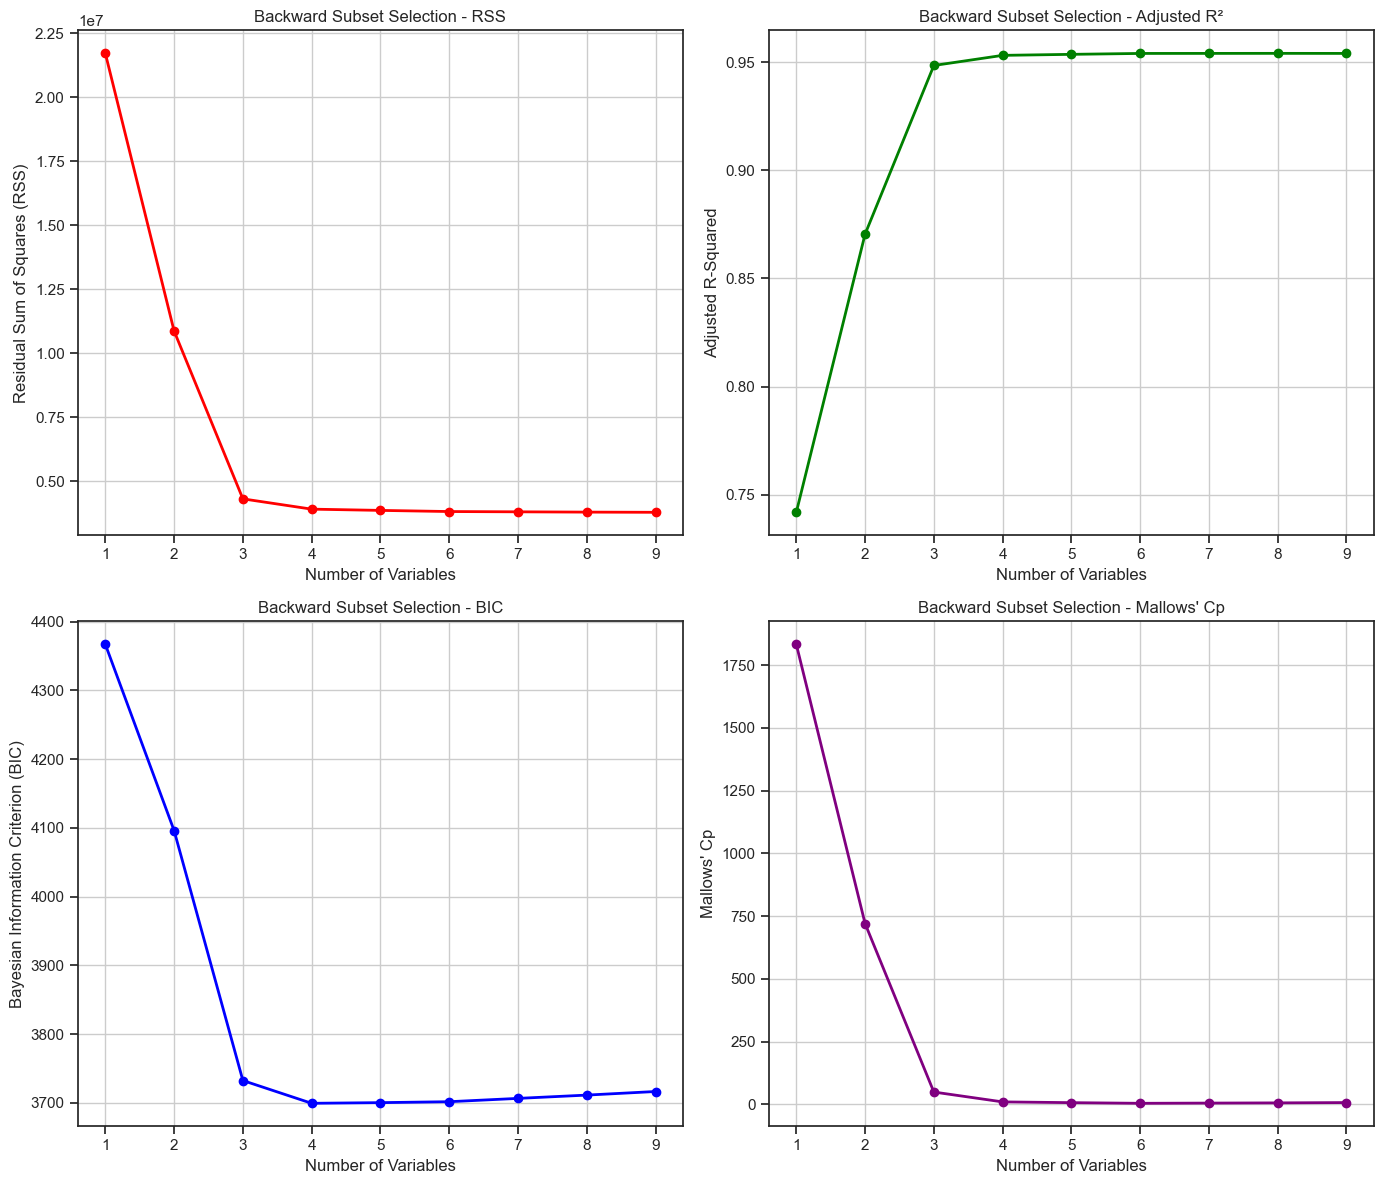


Selected features at each step (from 1 to max number of variables):
Variables: 1, Features: ('Limit',)
Variables: 2, Features: ('Income', 'Limit')
Variables: 3, Features: ('Income', 'Limit', 'Student')
Variables: 4, Features: ('Income', 'Limit', 'Cards', 'Student')
Variables: 5, Features: ('Income', 'Limit', 'Rating', 'Cards', 'Student')
Variables: 6, Features: ('Income', 'Limit', 'Rating', 'Cards', 'Age', 'Student')
Variables: 7, Features: ('Income', 'Limit', 'Rating', 'Cards', 'Age', 'Student', 'Ethnicity')
Variables: 8, Features: ('Income', 'Limit', 'Rating', 'Cards', 'Age', 'Gender', 'Student', 'Ethnicity')
Variables: 9, Features: ('Income', 'Limit', 'Rating', 'Cards', 'Age', 'Gender', 'Student', 'Married', 'Ethnicity')


In [6]:
######## backward subset selection on Credit data
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Function to compute evaluation metrics
def compute_metrics(y, y_pred, p, n, sigma2):
    rss = np.sum((y - y_pred) ** 2)
    tss = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - rss / tss
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    bic = n * np.log(rss / n) + p * np.log(n)
    cp = rss / sigma2 - n + 2 * p
    return rss, adj_r2, bic, cp

# ---------------------------------------------------
# 1. Load and Preview the Credit Dataset
# ---------------------------------------------------
Credit = pd.read_csv('Credit.csv')
Credit = Credit.drop('ID', axis=1)
print(Credit.head(10))
[num_samples,num_predictors]=Credit.shape

Credit['Gender'] = Credit['Gender'].map({' Male': 1, 'Female': 0})
Credit['Student'] = Credit['Student'].map({'Yes': 1, 'No': 0})
Credit['Married'] = Credit['Married'].map({'Yes': 1, 'No': 0})
Credit['Ethnicity'] = Credit['Ethnicity'].map({"Asian": 2, 'Caucasian': 1, 'African American': 0})
# ---------------------------------------------------
# 2. Backward Subset Selection
# ---------------------------------------------------

# Define response and predictors
y = Credit['Balance']
X = Credit.drop('Balance', axis=1)

# Fit the full model to estimate sigma^2 for Mallows' Cp
X_full = sm.add_constant(X)
full_model = sm.OLS(y, X_full).fit()
sigma2 = full_model.mse_resid

# Initialize lists to store metrics and selected features
min_features = 1
rss_list = []
adjr2_list = []
bic_list = []
cp_list = []
selected_features = []

# Initialize the list of selected and remaining features
current_features = list(X.columns)  # Start with all features for backward selection
remaining_features = list(X.columns)

n = len(y)  # Number of observations

# Perform Backward Subset Selection
for k in range(len(current_features), min_features , -1):
    best_rss = np.inf
    worst_feature = None
    best_model = None
    
    if k == 0:
        break  # No features left to remove
    
    # Iterate over current features to find the worst one to remove
    for feature in current_features:
        features_to_try = current_features.copy()
        features_to_try.remove(feature)
        X_subset = X[features_to_try]
        X_subset_const = sm.add_constant(X_subset)
        model = sm.OLS(y, X_subset_const).fit()
        rss = model.ssr  # Residual Sum of Squares
        
        if rss < best_rss:
            best_rss = rss
            worst_feature = feature
            best_model = model
    
    # Update the list of selected features by removing the worst feature
    current_features.remove(worst_feature)
    
    # Compute metrics for the best model at this step
    p = len(current_features)  # Number of predictors
    y_pred = best_model.fittedvalues
    rss, adjr2, bic, cp = compute_metrics(y, y_pred, p, n, sigma2)
    
    # Store the metrics and selected features
    rss_list.append(rss)
    adjr2_list.append(adjr2)
    bic_list.append(bic)
    cp_list.append(cp)
    selected_features.append(tuple(current_features))
    
    print(f"Number of variables: {p}, Removed feature: {worst_feature}, Remaining features: {current_features}")

# Reverse the lists to align with the number of variables (from 1 to max_features)
rss_list = rss_list[::-1]
adjr2_list = adjr2_list[::-1]
bic_list = bic_list[::-1]
cp_list = cp_list[::-1]
selected_features = selected_features[::-1]

# ---------------------------------------------------
# 3. Visualization of Selection Metrics
# ---------------------------------------------------

plt.figure(figsize=(14, 12))

# Plot RSS
plt.subplot(2, 2, 1)
plt.plot(range(1, len(rss_list) +1), rss_list, marker='o', color='red', linewidth=2)
plt.xlabel('Number of Variables')
plt.ylabel('Residual Sum of Squares (RSS)')
plt.title('Backward Subset Selection - RSS')
plt.grid(True)

# Plot Adjusted R-squared
plt.subplot(2, 2, 2)
plt.plot(range(1, len(adjr2_list) +1), adjr2_list, marker='o', color='green', linewidth=2)
plt.xlabel('Number of Variables')
plt.ylabel('Adjusted R-Squared')
plt.title('Backward Subset Selection - Adjusted R²')
plt.grid(True)

# Plot BIC
plt.subplot(2, 2, 3)
plt.plot(range(1, len(bic_list) +1), bic_list, marker='o', color='blue', linewidth=2)
plt.xlabel('Number of Variables')
plt.ylabel('Bayesian Information Criterion (BIC)')
plt.title('Backward Subset Selection - BIC')
plt.grid(True)

# Plot Mallows' Cp
plt.subplot(2, 2, 4)
plt.plot(range(1, len(cp_list) +1), cp_list, marker='o', color='purple', linewidth=2)
plt.xlabel('Number of Variables')
plt.ylabel("Mallows' Cp")
plt.title("Backward Subset Selection - Mallows' Cp")
plt.grid(True)

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 4. Display Selected Features at Each Step
# ---------------------------------------------------

print("\nSelected features at each step (from 1 to max number of variables):")
for i, features in enumerate(selected_features, 1):
    print(f"Variables: {i}, Features: {features}")

    Income  Limit  Rating  Cards  Age  Education  Gender Student Married  \
0   14.891   3606     283      2   34         11    Male      No     Yes   
1  106.025   6645     483      3   82         15  Female     Yes     Yes   
2  104.593   7075     514      4   71         11    Male      No      No   
3  148.924   9504     681      3   36         11  Female      No      No   
4   55.882   4897     357      2   68         16    Male      No     Yes   
5   80.180   8047     569      4   77         10    Male      No      No   
6   20.996   3388     259      2   37         12  Female      No      No   
7   71.408   7114     512      2   87          9    Male      No      No   
8   15.125   3300     266      5   66         13  Female      No      No   
9   71.061   6819     491      3   41         19  Female     Yes     Yes   

          Ethnicity  Balance  
0         Caucasian      333  
1             Asian      903  
2             Asian      580  
3             Asian      964  
4       

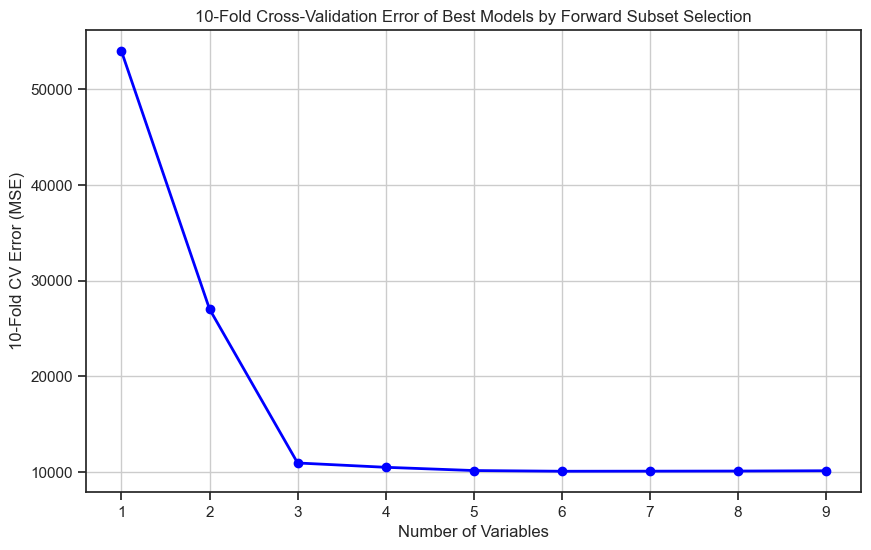

In [8]:
############ use 10-CV as the criterion in forward subset selection 
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# ---------------------------------------------------
# 1. Load and Preview the Credit Dataset
# ---------------------------------------------------
Credit = pd.read_csv('Credit.csv')
Credit = Credit.drop('ID', axis=1)
print(Credit.head(10))
[num_samples,num_predictors]=Credit.shape

Credit['Gender'] = Credit['Gender'].map({' Male': 1, 'Female': 0})
Credit['Student'] = Credit['Student'].map({'Yes': 1, 'No': 0})
Credit['Married'] = Credit['Married'].map({'Yes': 1, 'No': 0})
Credit['Ethnicity'] = Credit['Ethnicity'].map({"Asian": 2, 'Caucasian': 1, 'African American': 0})

# ---------------------------------------------------
# 2. Forward Subset Selection
# ---------------------------------------------------

# Define response and predictors
X = Credit.drop('Balance', axis=1)
y = Credit['Balance']
X_features = X

# Initialize the Linear Regression model
model = LinearRegression()

# Initialize Sequential Forward Selection (SFS) using mlxtend
# mlxtend's SFS selects features by adding one at a time (forward selection)
sfs = SFS(model,
          k_features=10,          # Maximum number of features to select
          forward=True,
          floating=False,
          scoring='neg_mean_squared_error',
          cv=10)

# Perform SFS
sfs = sfs.fit(X_features, y)

# Extract the selected features for each number of variables
selected_features = list(sfs.subsets_.keys())  # Number of features selected
selected_features_sorted = sorted(selected_features)

# Create a list to store features selected at each step
features_at_step = []
for k in range(1, 10):
    # sfs.subsets_ is a dictionary where keys are the number of selected features
    # and values are dictionaries containing 'feature_names' and 'avg_score'
    if k in sfs.subsets_:
        features = sfs.subsets_[k]['feature_names']
        features_at_step.append(list(features))
    else:
        # If not available, append the last best
        features_at_step.append(features_at_step[-1])

print("\nSelected features at each step (Forward Subset Selection):")
for idx, features in enumerate(features_at_step, 1):
    print(f"Variables: {idx}, Features: {features}")

# ---------------------------------------------------
# 3. 10-Fold Cross-Validation Errors of Best Models
# ---------------------------------------------------

from sklearn.metrics import mean_squared_error

# Initialize list to store CV errors
CV10_err = []

# Define 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=1)

for p in range(1, 10):
    features = features_at_step[p-1]
    X_subset = X_features[features]
    # Initialize Linear Regression model
    lr = LinearRegression()
    # Compute negative MSE for each fold
    neg_mse_scores = cross_val_score(lr, X_subset, y, scoring='neg_mean_squared_error', cv=kf)
    # Compute average MSE
    mse = -neg_mse_scores.mean()
    CV10_err.append(mse)
    print(f"Number of variables: {p}, CV Error (MSE): {mse:.4f}")

# ---------------------------------------------------
# 4. Visualization of CV Errors
# ---------------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(range(1, 10), CV10_err, marker='o', color='blue', linewidth=2)
plt.xlabel('Number of Variables')
plt.ylabel('10-Fold CV Error (MSE)')
plt.title('10-Fold Cross-Validation Error of Best Models by Forward Subset Selection')
plt.xticks(range(1, 10))
plt.grid(True)
plt.show()

    Income  Limit  Rating  Cards  Age  Education  Gender Student Married  \
0   14.891   3606     283      2   34         11    Male      No     Yes   
1  106.025   6645     483      3   82         15  Female     Yes     Yes   
2  104.593   7075     514      4   71         11    Male      No      No   
3  148.924   9504     681      3   36         11  Female      No      No   
4   55.882   4897     357      2   68         16    Male      No     Yes   
5   80.180   8047     569      4   77         10    Male      No      No   
6   20.996   3388     259      2   37         12  Female      No      No   
7   71.408   7114     512      2   87          9    Male      No      No   
8   15.125   3300     266      5   66         13  Female      No      No   
9   71.061   6819     491      3   41         19  Female     Yes     Yes   

          Ethnicity  Balance  
0         Caucasian      333  
1             Asian      903  
2             Asian      580  
3             Asian      964  
4       

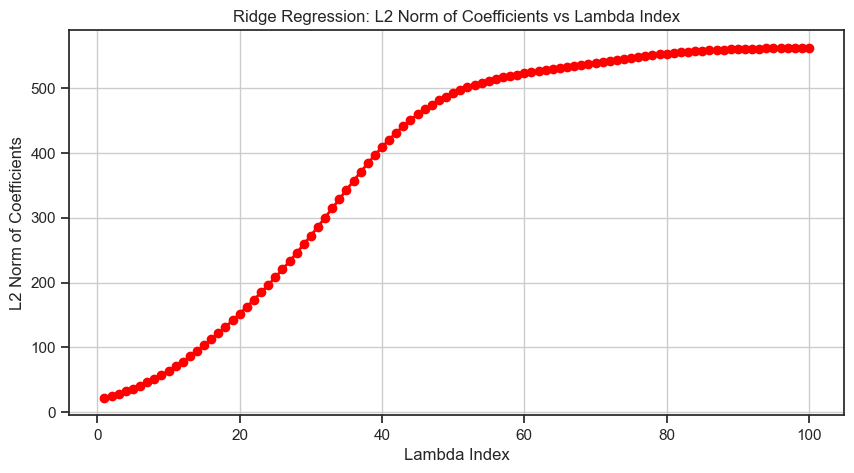

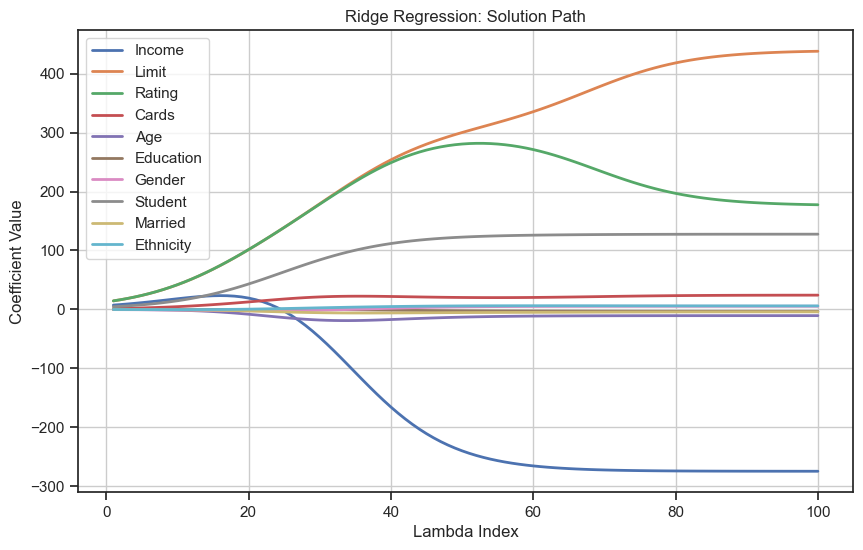


10-fold CV Error with lambda=4: 9997.8474
10-fold CV Error with lambda=1e10 (using closest lambda=10000.0000): 193245.8243

Best lambda from cross-validation: 0.2154
10-fold CV Error with best lambda=0.2154: 9245.4206

Ridge Regression Coefficients on Full Dataset with lambda=0.2154:
{'Income': -274.00000687717886, 'Limit': 412.8039632072831, 'Rating': 202.28105682187226, 'Cards': 23.129892041941577, 'Age': -10.652631923333301, 'Education': -3.3095295764156862, 'Gender': 5.310690009035751, 'Student': 127.43138237642302, 'Married': -4.354511517056423, 'Ethnicity': 6.047702532704927}
Intercept: 520.0150


In [9]:
####### Ridge regression on Credit Data
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# ---------------------------------------------------
# 1. Load and Preview the Credit Dataset
# ---------------------------------------------------

Credit = pd.read_csv('Credit.csv')
Credit = Credit.drop('ID', axis=1)
print(Credit.head(10))
[num_samples,num_predictors]=Credit.shape

Credit['Gender'] = Credit['Gender'].map({' Male': 1, 'Female': 0})
Credit['Student'] = Credit['Student'].map({'Yes': 1, 'No': 0})
Credit['Married'] = Credit['Married'].map({'Yes': 1, 'No': 0})
Credit['Ethnicity'] = Credit['Ethnicity'].map({"Asian": 2, 'Caucasian': 1, 'African American': 0})

n_features = 10  # Number of predictors
feature_names = Credit.columns[:-1].tolist()

# ---------------------------------------------------
# 2. Ridge Regression
# ---------------------------------------------------

# Define response and predictors
y = Credit['Balance'].values
X_features = Credit.drop('Balance', axis=1).values
n_samples=len(y)

# Standardize the predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Define the lambda grid (equivalent to alpha in sklearn's Ridge)
# In sklearn, alpha = lambda
lambda_grid = 10 ** np.linspace(4, -2, 100)

# Initialize an array to store coefficients for each lambda
coef_matrix = np.zeros((len(lambda_grid), X_features.shape[1]))

# Fit Ridge Regression models for each lambda and store the coefficients
for i, lam in enumerate(lambda_grid):
    ridge = Ridge(alpha=lam, fit_intercept=True)
    ridge.fit(X_scaled, y)
    coef_matrix[i, :] = ridge.coef_

# Extract coefficients for the 50th and 60th models
# Note: Python uses 0-based indexing
index_50 = 49
index_60 = 59

coef_50 = coef_matrix[index_50, :]
coef_60 = coef_matrix[index_60, :]

print(f"\nLambda at 50th index: {lambda_grid[index_50]:.4f}")
print(f"Coefficients at 50th lambda:\n{dict(zip(feature_names, coef_50))}")
print(f"L2 norm of coefficients at 50th lambda: {np.linalg.norm(coef_50):.4f}")

print(f"\nLambda at 60th index: {lambda_grid[index_60]:.4f}")
print(f"Coefficients at 60th lambda:\n{dict(zip(feature_names, coef_60))}")
print(f"L2 norm of coefficients at 60th lambda: {np.linalg.norm(coef_60):.4f}")

# ---------------------------------------------------
# 3. Visualization of Coefficient Norms and Solution Path
# ---------------------------------------------------

# Calculate L2 norms of coefficients for all lambda values
l2_norms = np.linalg.norm(coef_matrix, axis=1)

# Plot L2 norm of coefficients vs lambda index
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(lambda_grid) + 1), l2_norms, marker='o', color='red', linewidth=2)
plt.xlabel('Lambda Index')
plt.ylabel('L2 Norm of Coefficients')
plt.title('Ridge Regression: L2 Norm of Coefficients vs Lambda Index')
plt.grid(True)
plt.show()

# Plot solution path for selected features
# Adjust the feature indices based on your dataset. Here, we'll select features X3, X4, X5, X10
# which correspond to indices 2, 3, 4, 9 (0-based indexing)
selected_features = feature_names
selected_indices = [feature_names.index(feat) for feat in selected_features]

plt.figure(figsize=(10, 6))
for idx, feature in zip(selected_indices, selected_features):
    plt.plot(range(1, len(lambda_grid) + 1), coef_matrix[:, idx], label=feature, linewidth=2)

plt.xlabel('Lambda Index')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression: Solution Path')
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------
# 4. Prediction and Evaluation
# ---------------------------------------------------

# Split the data into training and testing sets
# Using 50% of the data for training as in the R code
np.random.seed(1)
train_indices = np.random.choice(range(n_samples), size=n_samples // 2, replace=False)
test_indices = np.array(list(set(range(n_samples)) - set(train_indices)))

X_train, X_test = X_scaled[train_indices, :], X_scaled[test_indices, :]
y_train, y_test = y[train_indices], y[test_indices]

# Fit Ridge Regression on training data with the predefined lambda grid
ridge_models = []
for lam in lambda_grid:
    ridge = Ridge(alpha=lam, fit_intercept=True)
    ridge.fit(X_train, y_train)
    ridge_models.append(ridge)

# Predict on test data with lambda=4 (find the closest lambda in the grid)
lambda_4 = 4
closest_lambda_4 = min(lambda_grid, key=lambda x: abs(x - lambda_4))
index_lambda_4 = np.where(lambda_grid == closest_lambda_4)[0][0]
ridge_pred_4 = ridge_models[index_lambda_4].predict(X_test)
mse_lambda_4 = mean_squared_error(y_test, ridge_pred_4)
print(f"\n10-fold CV Error with lambda=4: {mse_lambda_4:.4f}")

# Predict on test data with lambda=1e10 (effectively zero coefficients)
lambda_1e10 = 1e10
# Since our grid goes from 10^4 to 10^-2, 1e10 is beyond the grid. We'll take the largest lambda in the grid.
closest_lambda_1e10 = min(lambda_grid, key=lambda x: abs(x - lambda_1e10))
index_lambda_1e10 = np.where(lambda_grid == closest_lambda_1e10)[0][0]
ridge_pred_1e10 = ridge_models[index_lambda_1e10].predict(X_test)
mse_lambda_1e10 = mean_squared_error(y_test, ridge_pred_1e10)
print(f"10-fold CV Error with lambda=1e10 (using closest lambda={closest_lambda_1e10:.4f}): {mse_lambda_1e10:.4f}")

# ---------------------------------------------------
# 5. Cross-Validation to Choose the Best Lambda
# ---------------------------------------------------

from sklearn.linear_model import RidgeCV

# Define cross-validation with the same lambda grid
ridge_cv = RidgeCV(alphas=lambda_grid, cv=10)
ridge_cv.fit(X_train, y_train)

# Best lambda that minimizes CV error
best_lambda = ridge_cv.alpha_
print(f"\nBest lambda from cross-validation: {best_lambda:.4f}")

# Predict on test data using the best lambda
ridge_best = Ridge(alpha=best_lambda, fit_intercept=True)
ridge_best.fit(X_train, y_train)
ridge_pred_best = ridge_best.predict(X_test)
mse_best_lambda = mean_squared_error(y_test, ridge_pred_best)
print(f"10-fold CV Error with best lambda={best_lambda:.4f}: {mse_best_lambda:.4f}")

# ---------------------------------------------------
# 6. Fit Ridge Regression on the Full Dataset with Best Lambda
# ---------------------------------------------------

ridge_full = Ridge(alpha=best_lambda, fit_intercept=True)
ridge_full.fit(X_scaled, y)
full_coefficients = ridge_full.coef_

print(f"\nRidge Regression Coefficients on Full Dataset with lambda={best_lambda:.4f}:")
print(dict(zip(feature_names, full_coefficients)))

# Optionally, include the intercept
print(f"Intercept: {ridge_full.intercept_:.4f}")

    Income  Limit  Rating  Cards  Age  Education  Gender Student Married  \
0   14.891   3606     283      2   34         11    Male      No     Yes   
1  106.025   6645     483      3   82         15  Female     Yes     Yes   
2  104.593   7075     514      4   71         11    Male      No      No   
3  148.924   9504     681      3   36         11  Female      No      No   
4   55.882   4897     357      2   68         16    Male      No     Yes   
5   80.180   8047     569      4   77         10    Male      No      No   
6   20.996   3388     259      2   37         12  Female      No      No   
7   71.408   7114     512      2   87          9    Male      No      No   
8   15.125   3300     266      5   66         13  Female      No      No   
9   71.061   6819     491      3   41         19  Female     Yes     Yes   

          Ethnicity  Balance  
0         Caucasian      333  
1             Asian      903  
2             Asian      580  
3             Asian      964  
4       

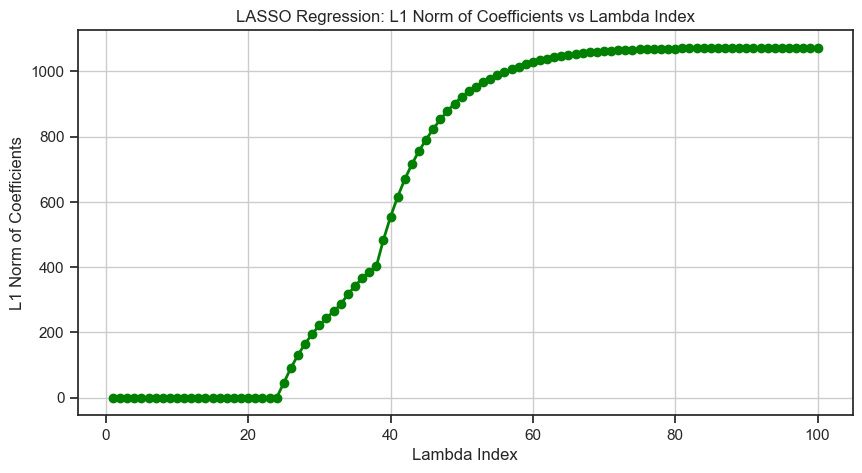

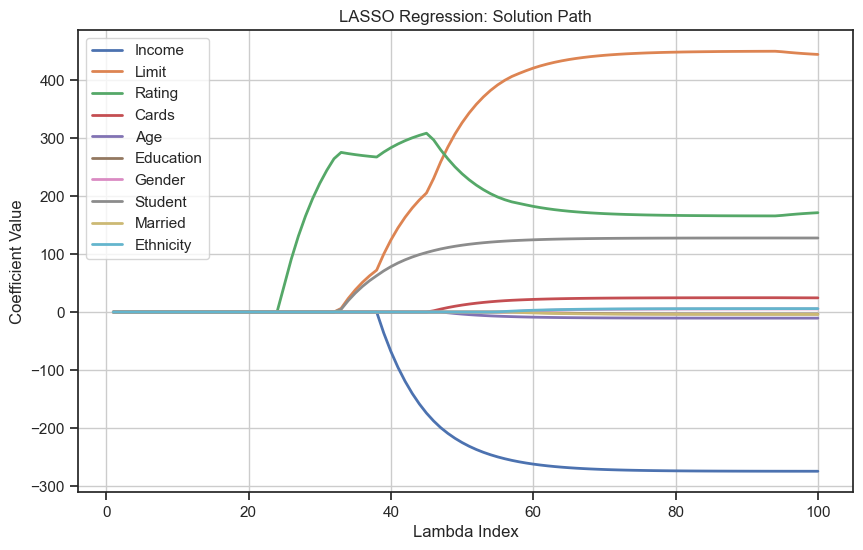


10-fold CV Error with lambda=10.7227: 10946.1396
10-fold CV Error with lambda=20 (using closest lambda=18.7382): 13833.0111

Best lambda from cross-validation: 0.8697
10-fold CV Error with best lambda=0.8697: 9460.4864

LASSO Regression Coefficients on Full Dataset with lambda=0.8697:
{'Income': -270.68056667952237, 'Limit': 440.52828056183785, 'Rating': 171.07768662823182, 'Cards': 23.736887228960555, 'Age': -10.001211492020596, 'Education': -2.595814675918641, 'Gender': 4.324970652924501, 'Student': 126.71802123294017, 'Married': -3.2444716708590446, 'Ethnicity': 4.966365913288896}
Intercept: 520.0150

Non-zero coefficients:
{'Income': -270.68056667952237, 'Limit': 440.52828056183785, 'Rating': 171.07768662823182, 'Cards': 23.736887228960555, 'Age': -10.001211492020596, 'Education': -2.595814675918641, 'Gender': 4.324970652924501, 'Student': 126.71802123294017, 'Married': -3.2444716708590446, 'Ethnicity': 4.966365913288896}

LASSO Coefficients with lambda=18.7382:
{'Income': -187.87

In [10]:
##### LASSO on Credit data
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# ---------------------------------------------------
# 1. Load and Preview the Credit Dataset
# ---------------------------------------------------

Credit = pd.read_csv('Credit.csv')
Credit = Credit.drop('ID', axis=1)
print(Credit.head(10))
[num_samples,num_predictors]=Credit.shape

Credit['Gender'] = Credit['Gender'].map({' Male': 1, 'Female': 0})
Credit['Student'] = Credit['Student'].map({'Yes': 1, 'No': 0})
Credit['Married'] = Credit['Married'].map({'Yes': 1, 'No': 0})
Credit['Ethnicity'] = Credit['Ethnicity'].map({"Asian": 2, 'Caucasian': 1, 'African American': 0})

n_features = 10  # Number of predictors
feature_names = Credit.columns[:-1].tolist()

# ---------------------------------------------------
# 2. LASSO Regression
# ---------------------------------------------------

# Define response and predictors
y = Credit['Balance'].values
X_features = Credit.drop('Balance', axis=1).values
n_samples=len(y)

# Standardize the predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Define the lambda grid (equivalent to alpha in scikit-learn's Lasso)
lambda_grid = 10 ** np.linspace(4, -2, 100)

# Initialize an array to store coefficients for each lambda
coef_matrix = np.zeros((len(lambda_grid), X_features.shape[1]))

# Fit LASSO models for each lambda and store the coefficients
for i, lam in enumerate(lambda_grid):
    lasso = Lasso(alpha=lam, fit_intercept=True, max_iter=10000)
    lasso.fit(X_scaled, y)
    coef_matrix[i, :] = lasso.coef_

# Extract coefficients for the 50th and 60th models
# Note: Python uses 0-based indexing
index_50 = 49
index_60 = 59

coef_50 = coef_matrix[index_50, :]
coef_60 = coef_matrix[index_60, :]

print(f"\nLambda at 50th index: {lambda_grid[index_50]:.4f}")
print(f"Coefficients at 50th lambda:")
print(dict(zip(feature_names, coef_50)))
print(f"L1 norm of coefficients at 50th lambda: {np.linalg.norm(coef_50, 1):.4f}")

print(f"\nLambda at 60th index: {lambda_grid[index_60]:.4f}")
print(f"Coefficients at 60th lambda:")
print(dict(zip(feature_names, coef_60)))
print(f"L1 norm of coefficients at 60th lambda: {np.linalg.norm(coef_60, 1):.4f}")

# ---------------------------------------------------
# 3. Visualization of Coefficient Norms and Solution Path
# ---------------------------------------------------

# Calculate L1 norms of coefficients for all lambda values
l1_norms = np.linalg.norm(coef_matrix, ord=1, axis=1)

# Plot L1 norm of coefficients vs lambda index
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(lambda_grid) + 1), l1_norms, marker='o', color='green', linewidth=2)
plt.xlabel('Lambda Index')
plt.ylabel('L1 Norm of Coefficients')
plt.title('LASSO Regression: L1 Norm of Coefficients vs Lambda Index')
plt.grid(True)
plt.show()

# Plot solution path for selected features
# Adjust the feature indices based on your dataset. Here, we'll select features Feature3, Feature4, Feature5, Feature10
# which correspond to indices 2, 3, 4, 9 (0-based indexing)
selected_features = feature_names
selected_indices = [feature_names.index(feat) for feat in selected_features]

plt.figure(figsize=(10, 6))
for idx, feature in zip(selected_indices, selected_features):
    plt.plot(range(1, len(lambda_grid) + 1), coef_matrix[:, idx], label=feature, linewidth=2)

plt.xlabel('Lambda Index')
plt.ylabel('Coefficient Value')
plt.title('LASSO Regression: Solution Path')
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------
# 4. Prediction and Evaluation
# ---------------------------------------------------

# Split the data into training and testing sets
# Using 50% of the data for training as in the R code
np.random.seed(1)
train_indices = np.random.choice(range(n_samples), size=n_samples // 2, replace=False)
test_indices = np.array(list(set(range(n_samples)) - set(train_indices)))

X_train, X_test = X_scaled[train_indices, :], X_scaled[test_indices, :]
y_train, y_test = y[train_indices], y[test_indices]

# Fit LASSO on training data with the predefined lambda grid
lasso_models = []
for lam in lambda_grid:
    lasso = Lasso(alpha=lam, fit_intercept=True, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_models.append(lasso)

# Predict on test data with lambda=50 (find the corresponding lambda in the grid)
# In R's glmnet, lambda is indexed starting at 1, but in Python it's 0-based
# Assuming the user wants to use the original index, lambda=50 -> index=49
# Here, lambda=50 is not in grid as grid has 100 values from 10^4 to 10^-2
# Instead, to demonstrate, use the 50th lambda
lambda_50 = lambda_grid[index_50]
lasso_pred_50 = lasso_models[index_50].predict(X_test)
mse_lambda_50 = mean_squared_error(y_test, lasso_pred_50)
print(f"\n10-fold CV Error with lambda={lambda_50:.4f}: {mse_lambda_50:.4f}")

# Predict on test data with lambda=20 (find the closest lambda in the grid)
lambda_20 = 20
closest_lambda_20 = min(lambda_grid, key=lambda x: abs(x - lambda_20))
index_lambda_20 = np.where(lambda_grid == closest_lambda_20)[0][0]
lasso_pred_20 = lasso_models[index_lambda_20].predict(X_test)
mse_lambda_20 = mean_squared_error(y_test, lasso_pred_20)
print(f"10-fold CV Error with lambda=20 (using closest lambda={closest_lambda_20:.4f}): {mse_lambda_20:.4f}")

# ---------------------------------------------------
# 5. Cross-Validation to Choose the Best Lambda
# ---------------------------------------------------

# Initialize LassoCV for cross-validation (10-fold CV by default)
lasso_cv = LassoCV(alphas=lambda_grid, cv=10, max_iter=10000, random_state=1)
lasso_cv.fit(X_train, y_train)

# Best lambda that minimizes CV error
best_lambda = lasso_cv.alpha_
print(f"\nBest lambda from cross-validation: {best_lambda:.4f}")

# Predict on test data using the best lambda
lasso_best = Lasso(alpha=best_lambda, fit_intercept=True, max_iter=10000)
lasso_best.fit(X_train, y_train)
lasso_pred_best = lasso_best.predict(X_test)
mse_best_lambda = mean_squared_error(y_test, lasso_pred_best)
print(f"10-fold CV Error with best lambda={best_lambda:.4f}: {mse_best_lambda:.4f}")

# ---------------------------------------------------
# 6. Fit LASSO on the Full Dataset with Best Lambda
# ---------------------------------------------------

lasso_full = Lasso(alpha=best_lambda, fit_intercept=True, max_iter=10000)
lasso_full.fit(X_scaled, y)
full_coefficients = lasso_full.coef_

print(f"\nLASSO Regression Coefficients on Full Dataset with lambda={best_lambda:.4f}:")
print(dict(zip(feature_names, full_coefficients)))

# Optionally, include the intercept
print(f"Intercept: {lasso_full.intercept_:.4f}")

# Display non-zero coefficients
non_zero_coefficients = {feat: coef for feat, coef in zip(feature_names, full_coefficients) if coef != 0}
print("\nNon-zero coefficients:")
print(non_zero_coefficients)

# ---------------------------------------------------
# 7. Fit LASSO with a Larger Lambda (e.g., lambda=20)
# ---------------------------------------------------

# As before, find the closest lambda in the grid to 20
lasso_lambda_20 = Lasso(alpha=closest_lambda_20, fit_intercept=True, max_iter=10000)
lasso_lambda_20.fit(X_scaled, y)
coeff_lambda_20 = lasso_lambda_20.coef_

print(f"\nLASSO Coefficients with lambda={closest_lambda_20:.4f}:")
print(dict(zip(feature_names, coeff_lambda_20)))

# Display non-zero coefficients
non_zero_coeff_lambda_20 = {feat: coef for feat, coef in zip(feature_names, coeff_lambda_20) if coef != 0}
print("\nNon-zero coefficients with lambda=20:")
print(non_zero_coeff_lambda_20)

In [11]:
############### KNN regression for best subset selection
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

def evaluate_subset(subset, X, y, model, scoring, cv_folds, random_state):
    X_subset = X[list(subset)]
    # Perform cross-validation
    scores = cross_val_score(model, X_subset, y, cv=KFold(n_splits=cv_folds, shuffle=True, random_state=random_state), scoring=scoring)
    mean_score = np.mean(scores)
    return (subset, -mean_score)

def best_subset_selection_parallel(X, y, model, scoring='neg_mean_squared_error', cv_folds=5, n_jobs=-1, random_state=42):
    feature_names = X.columns
    n_features = len(feature_names)
    results = []
    for k in range(1, n_features + 1):
        print(f"Evaluating {k}-feature subsets...")
        subsets = list(combinations(feature_names, k))
        subset_scores = Parallel(n_jobs=n_jobs)(delayed(evaluate_subset)(subset, X, y, model, scoring, cv_folds, random_state) for subset in subsets)
        results.extend(subset_scores)
    
    return results

def main():
    # Load the Dataset
    Credit = pd.read_csv('Credit.csv')
    Credit = Credit.drop('ID', axis=1)
    print(Credit.head(10))
    [num_samples,num_predictors]=Credit.shape
    Credit['Gender'] = Credit['Gender'].map({' Male': 1, 'Female': 0})
    Credit['Student'] = Credit['Student'].map({'Yes': 1, 'No': 0})
    Credit['Married'] = Credit['Married'].map({'Yes': 1, 'No': 0})
    Credit['Ethnicity'] = Credit['Ethnicity'].map({"Asian": 2, 'Caucasian': 1, 'African American': 0})
    X = Credit.drop('Balance', axis=1)
    y = Credit['Balance']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

    knn = KNeighborsRegressor(n_neighbors=10)
    print("Starting Best Subset Selection with KNN Regression (Parallel)...")
    results = best_subset_selection_parallel(X_scaled, y, model=knn, scoring='neg_mean_squared_error', cv_folds=5, n_jobs=-1, random_state=42)
    print("Best Subset Selection Completed.")
    results_df = pd.DataFrame(results, columns=['Features', 'CV_Score'])
    results_df = results_df.sort_values(by='CV_Score', ascending=True).reset_index(drop=True)

    print("\nTop 20 Best Feature Subsets:")
    print(results_df.head(20))
    best_features = results_df.iloc[0]['Features']
    print(f"\nBest feature subset: {best_features}")
    X_best = X_scaled[list(best_features)]
    final_scores = cross_val_score(knn, X_best, y, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='neg_mean_squared_error')
    final_rmse = np.sqrt(-final_scores)

    print(f"\nCross-Validated RMSE of the best model: {final_rmse}")
    print(f"Average RMSE: {final_rmse.mean():.4f}")
    print(f"Std of RMSE: {final_rmse.std():.4f}")

if __name__ == "__main__":
    main()

    Income  Limit  Rating  Cards  Age  Education  Gender Student Married  \
0   14.891   3606     283      2   34         11    Male      No     Yes   
1  106.025   6645     483      3   82         15  Female     Yes     Yes   
2  104.593   7075     514      4   71         11    Male      No      No   
3  148.924   9504     681      3   36         11  Female      No      No   
4   55.882   4897     357      2   68         16    Male      No     Yes   
5   80.180   8047     569      4   77         10    Male      No      No   
6   20.996   3388     259      2   37         12  Female      No      No   
7   71.408   7114     512      2   87          9    Male      No      No   
8   15.125   3300     266      5   66         13  Female      No      No   
9   71.061   6819     491      3   41         19  Female     Yes     Yes   

          Ethnicity  Balance  
0         Caucasian      333  
1             Asian      903  
2             Asian      580  
3             Asian      964  
4       

In [13]:
############### KNN regression for best subset selection with noisy variables
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

def evaluate_subset(subset, X, y, model, scoring, cv_folds, random_state):
    X_subset = X[list(subset)]
    # Perform cross-validation
    scores = cross_val_score(model, X_subset, y, cv=KFold(n_splits=cv_folds, shuffle=True, random_state=random_state), scoring=scoring)
    mean_score = np.mean(scores)
    return (subset, -mean_score)

def best_subset_selection_parallel(X, y, model, scoring='neg_mean_squared_error', cv_folds=5, n_jobs=-1, random_state=42):
    feature_names = X.columns
    #n_features = len(feature_names)  ######## maximum model size
    n_features=4
    results = []
    for k in range(1, n_features + 1):
        print(f"Evaluating {k}-feature subsets...")
        subsets = list(combinations(feature_names, k))
        subset_scores = Parallel(n_jobs=n_jobs)(delayed(evaluate_subset)(subset, X, y, model, scoring, cv_folds, random_state) for subset in subsets)
        results.extend(subset_scores)
    
    return results

def main():
    # Load the Dataset
    Credit = pd.read_csv('Credit.csv')
    Credit = Credit.drop('ID', axis=1)
    [num_samples,num_predictors]=Credit.shape
    Credit['Gender'] = Credit['Gender'].map({' Male': 1, 'Female': 0})
    Credit['Student'] = Credit['Student'].map({'Yes': 1, 'No': 0})
    Credit['Married'] = Credit['Married'].map({'Yes': 1, 'No': 0})
    Credit['Ethnicity'] = Credit['Ethnicity'].map({"Asian": 2, 'Caucasian': 1, 'African American': 0})
    ###### create noisy columns
    column_names = [f'Noisy{i}' for i in range(1, 20 + 1)]
    data = {col: np.random.normal(loc=0, scale=1, size=400) for col in column_names}
    Credit=pd.concat([Credit, pd.DataFrame(data)], axis=1, sort=False)
    print(Credit.head(4))
    
    X = Credit.drop('Balance', axis=1)
    y = Credit['Balance']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

    knn = KNeighborsRegressor(n_neighbors=10)
    print("Starting Best Subset Selection with KNN Regression (Parallel)...")
    results = best_subset_selection_parallel(X_scaled, y, model=knn, scoring='neg_mean_squared_error', cv_folds=5, n_jobs=-1, random_state=42)
    print("Best Subset Selection Completed.")
    results_df = pd.DataFrame(results, columns=['Features', 'CV_Score'])
    results_df = results_df.sort_values(by='CV_Score', ascending=True).reset_index(drop=True)

    print("\nTop 20 Best Feature Subsets:")
    print(results_df.head(20))
    best_features = results_df.iloc[0]['Features']
    print(f"\nBest feature subset: {best_features}")
    X_best = X_scaled[list(best_features)]
    final_scores = cross_val_score(knn, X_best, y, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='neg_mean_squared_error')
    final_rmse = np.sqrt(-final_scores)

    print(f"\nCross-Validated RMSE of the best model: {final_rmse}")
    print(f"Average RMSE: {final_rmse.mean():.4f}")
    print(f"Std of RMSE: {final_rmse.std():.4f}")

if __name__ == "__main__":
    main()

    Income  Limit  Rating  Cards  Age  Education  Gender  Student  Married  \
0   14.891   3606     283      2   34         11       1        0        1   
1  106.025   6645     483      3   82         15       0        1        1   
2  104.593   7075     514      4   71         11       1        0        0   
3  148.924   9504     681      3   36         11       0        0        0   

   Ethnicity  ...   Noisy11   Noisy12   Noisy13   Noisy14   Noisy15   Noisy16  \
0          1  ...  1.858015 -0.273987  0.485436  0.788561 -1.344780 -3.237861   
1          2  ... -0.999584 -0.233156 -0.355549  0.525163 -1.452516 -1.184951   
2          2  ... -0.265462  0.243274 -0.758766 -1.525426 -0.306926 -0.674354   
3          2  ... -1.257672  1.660282  0.210277 -1.435653 -0.036096  1.025700   

    Noisy17   Noisy18   Noisy19   Noisy20  
0 -0.635540  1.644209  0.476084 -1.201069  
1 -0.283837  1.324700 -2.238627 -1.340834  
2 -1.145163  1.199386 -0.652121  0.716091  
3  1.210488 -0.732081  1.25

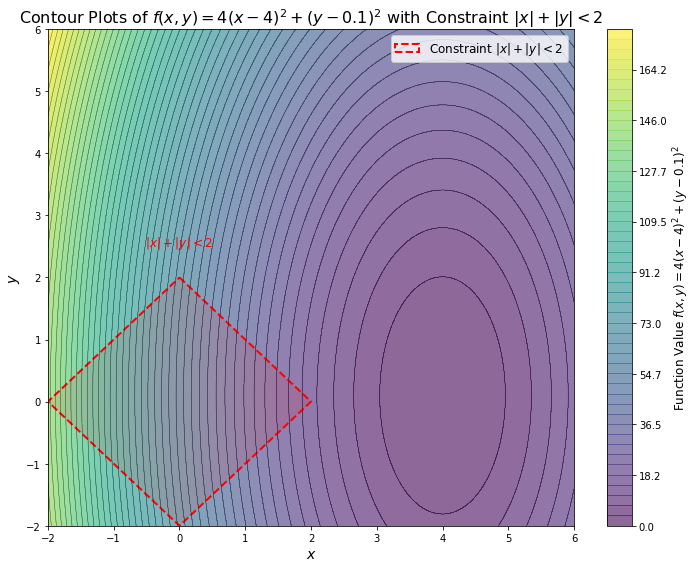

In [8]:
####### draw the contour plots and illustrate the constrained geometry optimization
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Define the function
def f(x, y):
    return 4*(x - 4)**2 + (y - 0.1)**2

# Define the range for x and y
x_min, x_max = -2, 6
y_min, y_max = -2, 6

# Define the number of points in each direction
num_points = 400

# Create a grid of x and y values
x = np.linspace(x_min, x_max, num_points)
y = np.linspace(y_min, y_max, num_points)
X, Y = np.meshgrid(x, y)

# Compute Z values for the function
Z = f(X, Y)

# Initialize the plot
plt.figure(figsize=(10, 8))

# Define contour levels
levels = np.linspace(np.min(Z), np.max(Z), 50)

# Plot filled contour
contour_filled = plt.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.6)

# Add contour lines
contour_lines = plt.contour(X, Y, Z, levels=levels, colors='k', linewidths=0.5, alpha=0.5)

# Add a colorbar
cbar = plt.colorbar(contour_filled)
cbar.set_label('Function Value $f(x, y) = 4(x-4)^2 + (y-0.1)^2$', fontsize=12)

# Define the vertices of the diamond (|x| + |y| = 2)
diamond_vertices = np.array([
    [0, 2],    # Top
    [2, 0],    # Right
    [0, -2],   # Bottom
    [-2, 0]    # Left
])

# Create a Polygon patch for the constraint boundary
diamond = Polygon(diamond_vertices, closed=True, facecolor='none', edgecolor='red', linewidth=2, linestyle='--')

# Add the diamond to the plot
plt.gca().add_patch(diamond)

# Fill the constraint region |x| + |y| < 2 with a semi-transparent color
diamond_fill = Polygon(diamond_vertices, closed=True, facecolor='red', edgecolor='none', alpha=0.1)
plt.gca().add_patch(diamond_fill)

# Annotate the constraint
plt.text(0, 2.5, '$|x| + |y| < 2$', color='red', fontsize=12, ha='center')

# Set plot limits
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

# Add labels and title
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.title('Contour Plots of $f(x, y) = 4(x-4)^2 + (y-0.1)^2$ with Constraint $|x| + |y| < 2$', fontsize=16)

# Add a legend for the constraint
plt.legend([diamond], ['Constraint $|x| + |y| < 2$'], loc='upper right', fontsize=12)

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()

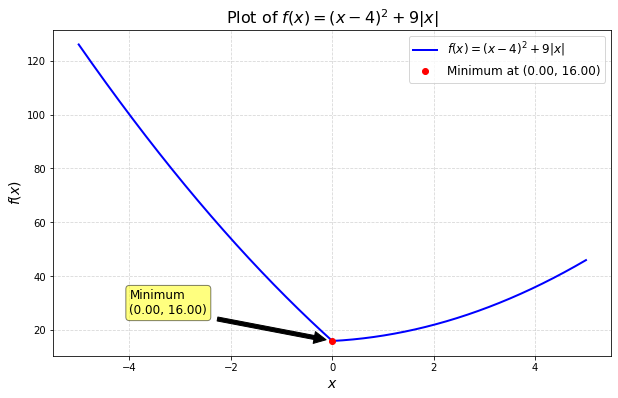

In [17]:
############### plot the function (x-2)^2+3|x| to visualize its minimizer
import numpy as np
import matplotlib.pyplot as plt

# Define the function
def f(x):
    return (x - 4)**2 + 9 * np.abs(x)

# Define the range for x
x_min, x_max = -5, 5

# Generate 400 points between x_min and x_max
x = np.linspace(x_min, x_max, 10000)

# Compute y values using the function
y = f(x)

# Find the index of the minimum y value
min_index = np.argmin(y)

# Corresponding x and y coordinates of the minimum point
x_min_point = x[min_index]
y_min_point = y[min_index]

# Initialize the plot
plt.figure(figsize=(10, 6))

# Plot the function
plt.plot(x, y, label=r'$f(x) = (x - 4)^2 + 9|x|$', color='blue', linewidth=2)

# Highlight the minimum point
plt.plot(x_min_point, y_min_point, 'ro', label=f'Minimum at ({x_min_point:.2f}, {y_min_point:.2f})')

# Add title and labels
plt.title(r'Plot of $f(x) = (x - 4)^2 + 9|x|$', fontsize=16)
plt.xlabel(r'$x$', fontsize=14)
plt.ylabel(r'$f(x)$', fontsize=14)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.5)

# Add legend to explain plot elements
plt.legend(fontsize=12)

# Optionally, annotate the minimum point with an arrow
plt.annotate(f'Minimum\n({x_min_point:.2f}, {y_min_point:.2f})',
             xy=(x_min_point, y_min_point),
             xytext=(x_min_point - 4, y_min_point + 10),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='yellow', alpha=0.5))

# Show the plot
plt.show()